In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install pymoo librosa scikit-learn numpy pandas matplotlib seaborn tqdm Pillow scipy

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import time
import gc
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, f1_score, 
                             roc_auc_score, average_precision_score)

# pymoo
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"🌱 Seed: {SEED}")
print("✅ Configuração completa!")

🖥️  Device: cuda
🎮 GPU: NVIDIA GeForce RTX 3050 Laptop GPU
💾 VRAM: 4.29 GB
🌱 Seed: 42
✅ Configuração completa!


In [ ]:
class GTZANSpectrogramDataset(Dataset):
    """Dataset GTZAN: carrega espectrogramas PNG organizados por gênero"""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        
        # Listar todas as pastas (gêneros)
        class_folders = sorted([d for d in self.root_dir.iterdir() if d.is_dir()])
        
        for idx, class_folder in enumerate(class_folders):
            self.class_to_idx[class_folder.name] = idx
            
            # Listar todos os PNGs
            for img_path in class_folder.glob("*.png"):
                self.samples.append((str(img_path), idx))
        
        print(f"✓ {len(self.samples)} amostras carregadas")
        print(f"✓ {len(self.class_to_idx)} gêneros: {list(self.class_to_idx.keys())}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Transformações
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet
                        std=[0.229, 0.224, 0.225])
])

# Caminho do dataset
GTZAN_PATH = r"My/Drive/Colab Notebooks/GTZAN_Spectrograms"

print("\n📂 Carregando GTZAN...")
full_dataset = GTZANSpectrogramDataset(GTZAN_PATH, transform=transform)

# Informações
num_classes = len(full_dataset.class_to_idx)
num_samples = len(full_dataset)

# Split 70/15/15
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n✓ Treino: {len(train_dataset)} ({len(train_dataset)/num_samples*100:.1f}%)")
print(f"✓ Validação: {len(val_dataset)} ({len(val_dataset)/num_samples*100:.1f}%)")
print(f"✓ Teste: {len(test_dataset)} ({len(test_dataset)/num_samples*100:.1f}%)")



📂 Carregando GTZAN...
✓ 999 amostras carregadas
✓ 10 gêneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

✓ Treino: 699 (70.0%)
✓ Validação: 149 (14.9%)
✓ Teste: 151 (15.1%)


In [5]:
class TransferLearningModel(nn.Module):
    """Modelo com backbone congelado + classificador treinável"""
    
    def __init__(self, model_idx, num_classes):
        super(TransferLearningModel, self).__init__()
        
        # Selecionar backbone
        if model_idx == 0:
            self.backbone = models.resnet18(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.model_name = "ResNet18"
        elif model_idx == 1:
            self.backbone = models.resnet34(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.model_name = "ResNet34"
        elif model_idx == 2:
            self.backbone = models.mobilenet_v2(pretrained=True)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            self.model_name = "MobileNetV2"
        else:  # model_idx == 3
            self.backbone = models.efficientnet_b0(pretrained=True)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            self.model_name = "EfficientNet-B0"
        
        # Congelar backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Classificador treinável
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

print("✓ Modelos disponíveis: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0")
print(f"✓ Classificador para {num_classes} classes")


✓ Modelos disponíveis: ResNet18, ResNet34, MobileNetV2, EfficientNet-B0
✓ Classificador para 10 classes


In [6]:
SEARCH_SPACE = {
    'learning_rate': (5e-5, 1e-2, 'log'),     # [0] Taxa de aprendizado
    'optimizer': (0, 2),                       # [1] 0=Adam, 1=SGD, 2=AdamW
    'epochs': (15, 30),                        # [2] Número de épocas
    'loss': (0, 1),                           # [3] 0=CrossEntropy, 1=LabelSmoothing
    'weight_decay': (1e-6, 5e-4, 'log'),     # [4] Regularização
    'model_idx': (0, 3),                      # [5] Índice do modelo (0-3)
    'batch_size': (16, 64),                   # [6] Tamanho do batch
    'lr_scheduler': (0, 1),                   # [7] 0=None, 1=CosineAnnealing
}

# Bounds para pymoo
xl = np.array([0.0, 0, 15, 0, 0.0, 0, 16, 0])  # Lower
xu = np.array([1.0, 2, 30, 1, 1.0, 3, 64, 1])  # Upper

def decode_individual(x):
    """Decodifica vetor [0,1] em hiperparâmetros reais"""
    return {
        'learning_rate': 10 ** (np.log10(5e-5) + x[0] * (np.log10(1e-2) - np.log10(5e-5))),
        'optimizer': int(np.round(x[1])),
        'epochs': int(np.round(x[2])),
        'loss': int(np.round(x[3])),
        'weight_decay': 10 ** (np.log10(1e-6) + x[4] * (np.log10(5e-4) - np.log10(1e-6))),
        'model_idx': int(np.round(x[5])),
        'batch_size': int(np.round(x[6])),
        'lr_scheduler': int(np.round(x[7])),
    }

print("✓ Espaço de busca definido:")
print("  - Learning Rate: 5e-5 a 1e-2")
print("  - Optimizers: Adam, SGD, AdamW")
print("  - Epochs: 15 a 30")
print("  - Models: 4 opções")
print("  - Batch Size: 16 a 64")
print("  - LR Scheduler: sim/não")

✓ Espaço de busca definido:
  - Learning Rate: 5e-5 a 1e-2
  - Optimizers: Adam, SGD, AdamW
  - Epochs: 15 a 30
  - Models: 4 opções
  - Batch Size: 16 a 64
  - LR Scheduler: sim/não


In [7]:
def evaluate_model(model, dataloader, criterion, device):
    """Avalia modelo e retorna métricas"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0
    
    num_classes_model = model.classifier[-1].out_features
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Métricas de Avaliação
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    # Métricas OOD
    try:
        auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        aupr = average_precision_score(
            np.eye(num_classes_model)[all_labels], all_probs, average='macro'
        )
    except:
        auroc = 0.5
        aupr = 0.1
    
    fpr = 1.0 - accuracy  # Simplificado
    avg_loss = total_loss / len(dataloader)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'f1': f1,
        'auroc': auroc,
        'aupr': aupr,
        'fpr': fpr,
        'val_loss': avg_loss
    }

def measure_performance(model, sample_input, device):
    """Mede latência e memória"""
    model.eval()
    sample_input = sample_input.to(device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_input)
    
    # Medir latência
    torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = model(sample_input)
    torch.cuda.synchronize()
    latency = (time.time() - start) / 100
    
    # Medir memória
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(sample_input)
    peak_memory = torch.cuda.max_memory_allocated() / 1e6  # MB
    
    return latency, peak_memory

print("✓ Funções de avaliação definidas")

✓ Funções de avaliação definidas


In [8]:

def evaluate_individual(params, gen, ind_num):
    """
    Treina e avalia um indivíduo
    Retorna: (fitness_eval, fitness_ood, fitness_perf)
    """
    
    # DataLoaders
    batch_size = int(params['batch_size'])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                             shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                           shuffle=False, num_workers=0, pin_memory=True)
    
    # Modelo
    model = TransferLearningModel(int(params['model_idx']), num_classes)
    model = model.to(device)
    
    # Otimizador
    if params['optimizer'] == 0:
        optimizer = optim.Adam(model.classifier.parameters(), 
                              lr=params['learning_rate'], 
                              weight_decay=params['weight_decay'])
    elif params['optimizer'] == 1:
        optimizer = optim.SGD(model.classifier.parameters(), 
                             lr=params['learning_rate'],
                             momentum=0.9, nesterov=True,
                             weight_decay=params['weight_decay'])
    else:
        optimizer = optim.AdamW(model.classifier.parameters(), 
                               lr=params['learning_rate'],
                               weight_decay=params['weight_decay'])
    
    # LR Scheduler
    scheduler = None
    if params['lr_scheduler'] == 1:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=params['epochs']
        )
    
    # Loss
    if params['loss'] == 0:
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Treinar com Early Stopping
    epochs = int(params['epochs'])
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    for epoch in range(epochs):
        # Treino
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        val_loss /= len(val_loader)
        
        # LR Scheduler
        if scheduler:
            scheduler.step()
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    # Avaliar
    metrics = evaluate_model(model, val_loader, criterion, device)
    
    # Performance
    sample_input = torch.randn(1, 3, 224, 224).to(device)
    latency, peak_memory = measure_performance(model, sample_input, device)
    
    # Normalizar performance (inverter para maximização)
    norm_latency = max(0, 1 - latency / 0.1)  # 100ms max
    norm_memory = max(0, 1 - peak_memory / 1000)  # 1000MB max
    
    # Calcular fitness (agregação simples)
    # EVAL: média ponderada de métricas
    fitness_eval = (
        0.4 * metrics['accuracy'] + 
        0.3 * metrics['f1'] + 
        0.2 * metrics['precision'] +
        0.1 * max(0, 1 - metrics['val_loss']/3.0)
    )
    
    # OOD: média de métricas OOD
    fitness_ood = (
        0.5 * metrics['auroc'] + 
        0.3 * metrics['aupr'] + 
        0.2 * (1 - metrics['fpr'])
    )
    
    # PERF: média de performance
    fitness_perf = 0.6 * norm_latency + 0.4 * norm_memory
    
    # Limpar memória
    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()
    
    return fitness_eval, fitness_ood, fitness_perf

print("✓ Função de fitness definida (3 objetivos)")

✓ Função de fitness definida (3 objetivos)


In [9]:

class MOOProblem(ElementwiseProblem):
    """Problema multi-objetivo: maximizar 3 fitness"""
    
    def __init__(self):
        super().__init__(
            n_var=8,      # 8 hiperparâmetros
            n_obj=3,      # 3 objetivos
            n_constr=0,   # Sem restrições
            xl=xl,
            xu=xu
        )
        self.generation = 0
        self.eval_counter = 0
    
    def _evaluate(self, x, out, *args, **kwargs):
        """Avalia um indivíduo"""
        self.eval_counter += 1
        
        # Decodificar
        params = decode_individual(x)
        
        # Avaliar
        f_eval, f_ood, f_perf = evaluate_individual(
            params, self.generation, self.eval_counter
        )
        
        # pymoo minimiza, então negamos (queremos maximizar)
        out["F"] = np.array([-f_eval, -f_ood, -f_perf])

problem = MOOProblem()
print("✓ Problema multi-objetivo definido")
print("  - 8 variáveis de decisão")
print("  - 3 objetivos: Eval, OOD, Performance")

✓ Problema multi-objetivo definido
  - 8 variáveis de decisão
  - 3 objetivos: Eval, OOD, Performance


In [10]:

# Configurar algoritmo
algorithm = NSGA2(
    pop_size=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# Termination
termination = get_termination("n_gen", 15)

# Histórico manual
history_data = {
    'gen': [],
    'avg_eval': [], 'avg_ood': [], 'avg_perf': [],
    'max_eval': [], 'max_ood': [], 'max_perf': [],
    'n_nds': []
}

# Callback
from pymoo.core.callback import Callback

class ProgressCallback(Callback):
    def notify(self, algorithm):
        problem.generation = algorithm.n_gen
        
        F = -algorithm.pop.get("F")  # Converter para positivo
        
        avg = F.mean(axis=0)
        max_f = F.max(axis=0)
        
        # Contar não-dominados
        nds = NonDominatedSorting()
        nds_idx = nds.do(algorithm.pop.get("F"), only_non_dominated_front=True)
        n_nds = len(nds_idx)
        
        history_data['gen'].append(algorithm.n_gen)
        history_data['avg_eval'].append(avg[0])
        history_data['avg_ood'].append(avg[1])
        history_data['avg_perf'].append(avg[2])
        history_data['max_eval'].append(max_f[0])
        history_data['max_ood'].append(max_f[1])
        history_data['max_perf'].append(max_f[2])
        history_data['n_nds'].append(n_nds)
        
        print(f"\n{'='*70}")
        print(f"GERAÇÃO {algorithm.n_gen}")
        print(f"  Avg: Eval={avg[0]:.3f}, OOD={avg[1]:.3f}, Perf={avg[2]:.3f}")
        print(f"  Max: Eval={max_f[0]:.3f}, OOD={max_f[1]:.3f}, Perf={max_f[2]:.3f}")
        print(f"  Não-dominados: {n_nds}")
        print(f"{'='*70}")

# Executar
print("\n🚀 Iniciando otimização NSGA-II...")
print(f"  População: 10 | Gerações: 15 | Tempo estimado: ~2h\n")

res = minimize(
    problem,
    algorithm,
    termination,
    callback=ProgressCallback(),
    seed=SEED,
    save_history=True,
    verbose=False
)

print("\n✅ Otimização concluída!")



🚀 Iniciando otimização NSGA-II...
  População: 10 | Gerações: 15 | Tempo estimado: ~2h


GERAÇÃO 1
  Avg: Eval=0.533, OOD=0.726, Perf=0.888
  Max: Eval=0.626, OOD=0.786, Perf=0.910
  Não-dominados: 3

GERAÇÃO 2
  Avg: Eval=0.583, OOD=0.758, Perf=0.901
  Max: Eval=0.651, OOD=0.788, Perf=0.910
  Não-dominados: 2

GERAÇÃO 3
  Avg: Eval=0.600, OOD=0.763, Perf=0.905
  Max: Eval=0.651, OOD=0.788, Perf=0.924
  Não-dominados: 3

GERAÇÃO 4
  Avg: Eval=0.626, OOD=0.779, Perf=0.907
  Max: Eval=0.651, OOD=0.788, Perf=0.924
  Não-dominados: 3

GERAÇÃO 5
  Avg: Eval=0.630, OOD=0.779, Perf=0.908
  Max: Eval=0.651, OOD=0.788, Perf=0.924
  Não-dominados: 3

GERAÇÃO 6
  Avg: Eval=0.630, OOD=0.778, Perf=0.890
  Max: Eval=0.651, OOD=0.788, Perf=0.924
  Não-dominados: 3

GERAÇÃO 7
  Avg: Eval=0.633, OOD=0.781, Perf=0.891
  Max: Eval=0.651, OOD=0.790, Perf=0.924
  Não-dominados: 5

GERAÇÃO 8
  Avg: Eval=0.635, OOD=0.781, Perf=0.891
  Max: Eval=0.654, OOD=0.790, Perf=0.924
  Não-dominados: 5

GERAÇÃO 9
  Av

In [11]:

# Extrair fronteira
pareto_F = -res.F  # Converter para positivo
pareto_X = res.X

print(f"\n{'='*70}")
print(f"FRONTEIRA DE PARETO - {len(pareto_X)} SOLUÇÕES")
print(f"{'='*70}\n")

# Criar DataFrame
pareto_results = []
for i in range(len(pareto_X)):
    params = decode_individual(pareto_X[i])
    
    pareto_results.append({
        'id': i+1,
        'fitness_eval': pareto_F[i, 0],
        'fitness_ood': pareto_F[i, 1],
        'fitness_perf': pareto_F[i, 2],
        'model': ['ResNet18', 'ResNet34', 'MobileNetV2', 'EfficientNet-B0'][params['model_idx']],
        'optimizer': ['Adam', 'SGD', 'AdamW'][params['optimizer']],
        'learning_rate': params['learning_rate'],
        'epochs': params['epochs'],
        'batch_size': params['batch_size'],
        'lr_scheduler': ['No', 'Yes'][params['lr_scheduler']],
    })

pareto_df = pd.DataFrame(pareto_results)

# Mostrar
print(pareto_df[['id', 'fitness_eval', 'fitness_ood', 'fitness_perf', 
                 'model', 'optimizer', 'epochs']].to_string(index=False))
print()

# Salvar
pareto_df.to_csv('pareto_front.csv', index=False)
print("✓ Salvo: pareto_front.csv")



FRONTEIRA DE PARETO - 10 SOLUÇÕES

 id  fitness_eval  fitness_ood  fitness_perf       model optimizer  epochs
  1      0.633878     0.792321      0.912024 MobileNetV2      Adam      18
  2      0.655392     0.783053      0.889867 MobileNetV2      Adam      18
  3      0.605249     0.769887      0.943223 MobileNetV2      Adam      17
  4      0.625718     0.774439      0.926552 MobileNetV2      Adam      18
  5      0.654237     0.780017      0.911171 MobileNetV2      Adam      18
  6      0.649404     0.788170      0.916636 MobileNetV2      Adam      18
  7      0.636416     0.779025      0.917566 MobileNetV2      Adam      17
  8      0.634671     0.771711      0.922628 MobileNetV2       SGD      18
  9      0.628008     0.784326      0.918144 MobileNetV2      Adam      19
 10      0.652598     0.790592      0.913522 MobileNetV2      Adam      18

✓ Salvo: pareto_front.csv


In [12]:

# Normalizar fitness para [0,1]
F_norm = pareto_F.copy()
for i in range(3):
    F_norm[:, i] = (F_norm[:, i] - F_norm[:, i].min()) / (F_norm[:, i].max() - F_norm[:, i].min() + 1e-12)

# Converter para minimização (indicadores assumem minimização)
F_min = 1.0 - F_norm

# Hypervolume
hv_ref = np.array([1.1, 1.1, 1.1])
hv_indicator = HV(ref_point=hv_ref)
hv_value = hv_indicator.do(F_min)

# Spread (diversidade)
from scipy.spatial.distance import cdist
dist_matrix = cdist(F_norm, F_norm)
np.fill_diagonal(dist_matrix, np.inf)
min_distances = dist_matrix.min(axis=1)
spacing = np.std(min_distances)

print(f"\n{'='*70}")
print("INDICADORES MULTI-OBJETIVO")
print(f"{'='*70}")
print(f"  Hypervolume: {hv_value:.4f}")
print(f"  Spacing (diversidade): {spacing:.4f} (menor = mais uniforme)")
print(f"  Número de soluções: {len(pareto_X)}")
print(f"{'='*70}\n")


INDICADORES MULTI-OBJETIVO
  Hypervolume: 0.7139
  Spacing (diversidade): 0.1235 (menor = mais uniforme)
  Número de soluções: 10



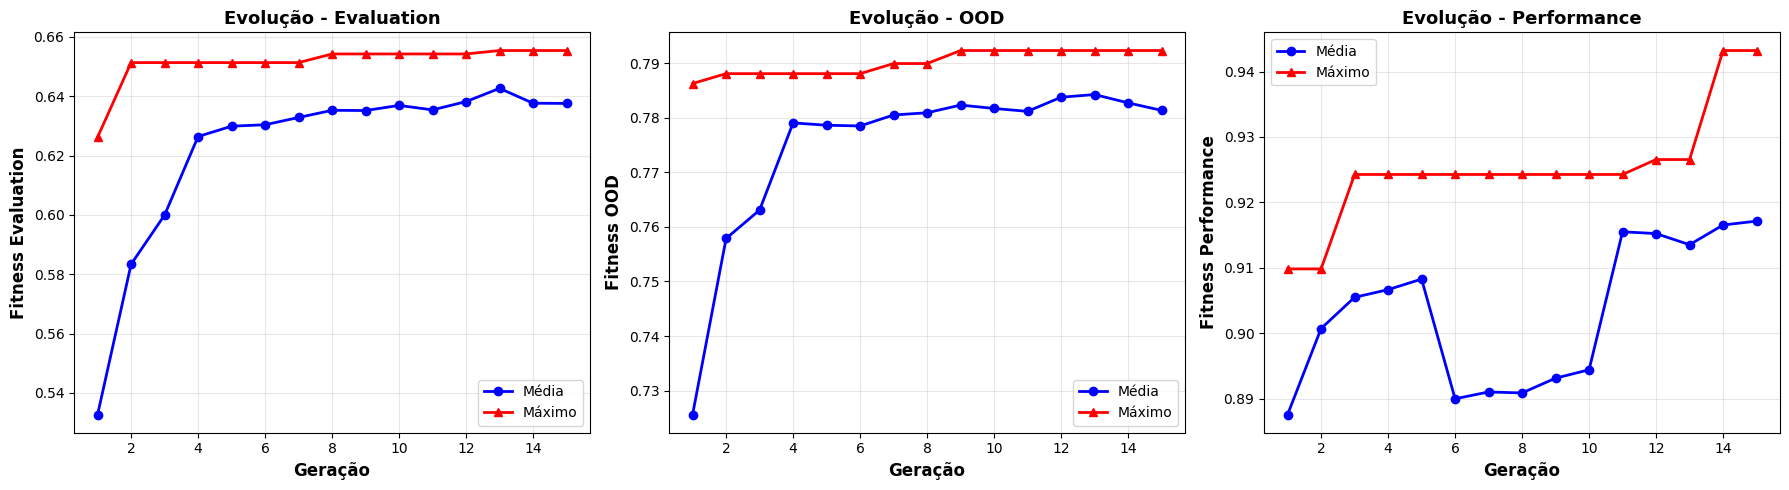

✓ Salvo: evolution.png


In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, name in zip(axes, 
                            [('avg_eval', 'max_eval'), 
                             ('avg_ood', 'max_ood'), 
                             ('avg_perf', 'max_perf')],
                            ['Evaluation', 'OOD', 'Performance']):
    
    ax.plot(history_data['gen'], history_data[metric[0]], 
           'b-o', label='Média', linewidth=2)
    ax.plot(history_data['gen'], history_data[metric[1]], 
           'r-^', label='Máximo', linewidth=2)
    
    ax.set_xlabel('Geração', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Fitness {name}', fontsize=12, fontweight='bold')
    ax.set_title(f'Evolução - {name}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Salvo: evolution.png")


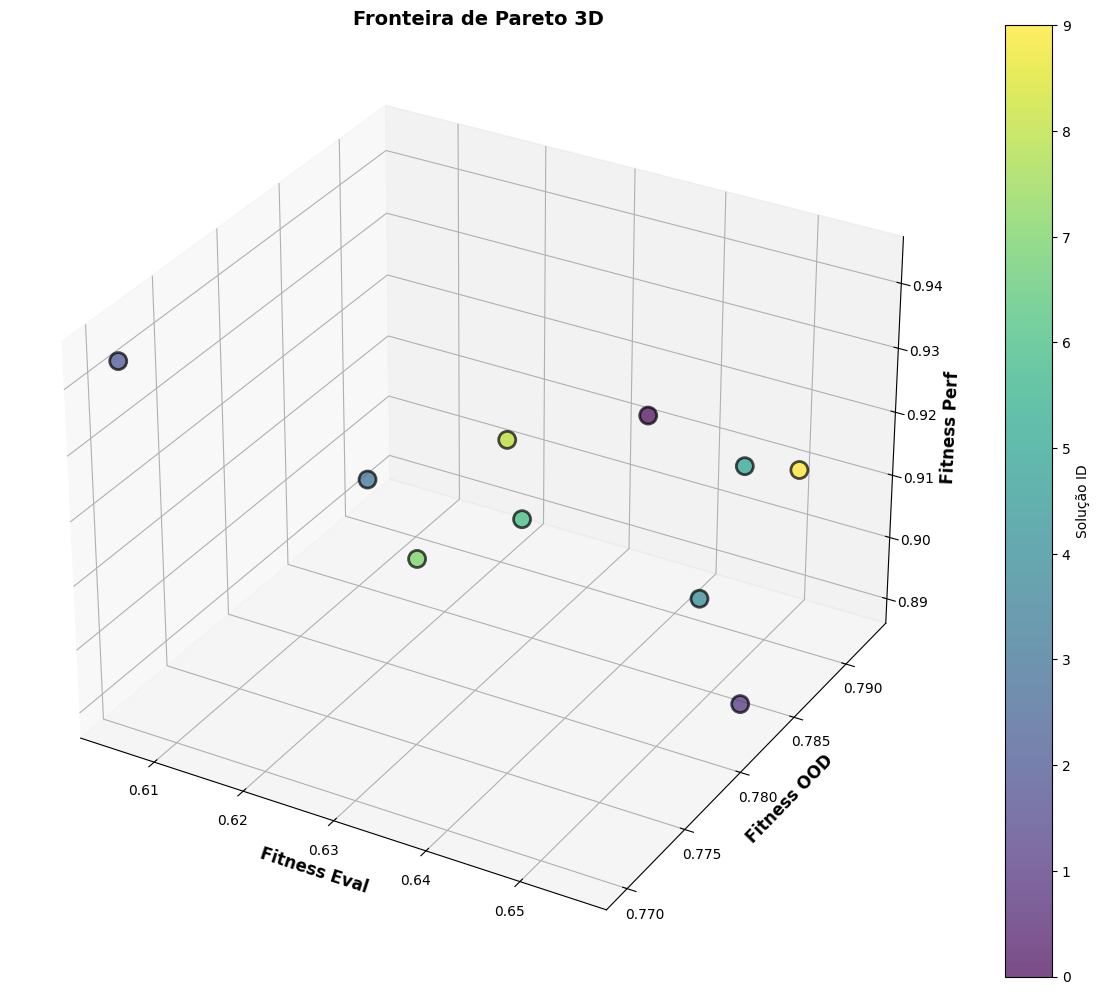

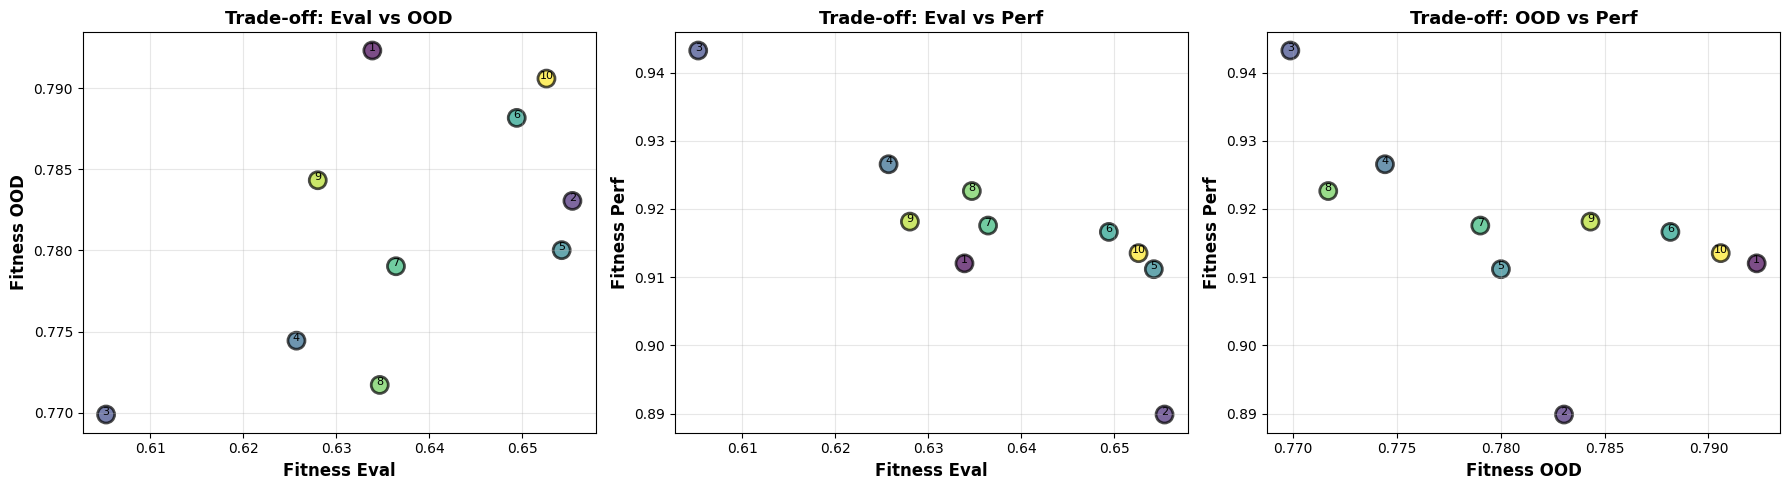

✓ Salvo: pareto_3d.png, pareto_tradeoffs.png


In [14]:

# 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pareto_F[:, 0], pareto_F[:, 1], pareto_F[:, 2],
                    c=range(len(pareto_F)), cmap='viridis', 
                    s=150, alpha=0.7, edgecolors='black', linewidth=2)

ax.set_xlabel('Fitness Eval', fontsize=12, fontweight='bold')
ax.set_ylabel('Fitness OOD', fontsize=12, fontweight='bold')
ax.set_zlabel('Fitness Perf', fontsize=12, fontweight='bold')
ax.set_title('Fronteira de Pareto 3D', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Solução ID')

plt.tight_layout()
plt.savefig('pareto_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# 2D Trade-offs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(0, 1, 'Eval', 'OOD'), (0, 2, 'Eval', 'Perf'), (1, 2, 'OOD', 'Perf')]

for ax, (i, j, name_i, name_j) in zip(axes, pairs):
    scatter = ax.scatter(pareto_F[:, i], pareto_F[:, j],
                        c=range(len(pareto_F)), cmap='viridis',
                        s=150, alpha=0.7, edgecolors='black', linewidth=2)
    
    ax.set_xlabel(f'Fitness {name_i}', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Fitness {name_j}', fontsize=12, fontweight='bold')
    ax.set_title(f'Trade-off: {name_i} vs {name_j}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Anotar pontos
    for k in range(len(pareto_F)):
        ax.annotate(f'{k+1}', (pareto_F[k, i], pareto_F[k, j]),
                   fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('pareto_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Salvo: pareto_3d.png, pareto_tradeoffs.png")

In [15]:


print(f"\n{'='*70}")
print("ANÁLISE DE TRADE-OFFS")
print(f"{'='*70}\n")

# Identificar soluções notáveis
best_eval_idx = pareto_F[:, 0].argmax()
best_ood_idx = pareto_F[:, 1].argmax()
best_perf_idx = pareto_F[:, 2].argmax()

# Solução balanceada (mais próxima do ideal)
ideal = np.array([1.0, 1.0, 1.0])
distances = np.linalg.norm(F_norm - ideal, axis=1)
balanced_idx = distances.argmin()

solutions = {
    '🎯 Best Evaluation': best_eval_idx,
    '🛡️  Best OOD': best_ood_idx,
    '⚡ Best Performance': best_perf_idx,
    '⚖️  Balanced': balanced_idx
}

for name, idx in solutions.items():
    sol = pareto_results[idx]
    print(f"{name}:")
    print(f"  ID: {sol['id']}")
    print(f"  Fitness: Eval={sol['fitness_eval']:.3f}, "
          f"OOD={sol['fitness_ood']:.3f}, Perf={sol['fitness_perf']:.3f}")
    print(f"  Model: {sol['model']}")
    print(f"  Optimizer: {sol['optimizer']}, LR={sol['learning_rate']:.2e}")
    print(f"  Epochs: {sol['epochs']}, Batch: {sol['batch_size']}")
    print()


ANÁLISE DE TRADE-OFFS

🎯 Best Evaluation:
  ID: 2
  Fitness: Eval=0.655, OOD=0.783, Perf=0.890
  Model: MobileNetV2
  Optimizer: Adam, LR=1.86e-03
  Epochs: 18, Batch: 49

🛡️  Best OOD:
  ID: 1
  Fitness: Eval=0.634, OOD=0.792, Perf=0.912
  Model: MobileNetV2
  Optimizer: Adam, LR=1.85e-03
  Epochs: 18, Batch: 49

⚡ Best Performance:
  ID: 3
  Fitness: Eval=0.605, OOD=0.770, Perf=0.943
  Model: MobileNetV2
  Optimizer: Adam, LR=1.86e-03
  Epochs: 17, Batch: 49

⚖️  Balanced:
  ID: 6
  Fitness: Eval=0.649, OOD=0.788, Perf=0.917
  Model: MobileNetV2
  Optimizer: Adam, LR=1.54e-03
  Epochs: 18, Batch: 49



In [16]:

print(f"\n{'='*70}")
print("RETREINANDO SOLUÇÃO BALANCEADA NO TESTE")
print(f"{'='*70}\n")

# Pegar solução balanceada
best_sol = pareto_results[balanced_idx]
best_X = pareto_X[balanced_idx]
best_params = decode_individual(best_X)

# Retreinar
batch_size = int(best_params['batch_size'])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = TransferLearningModel(int(best_params['model_idx']), num_classes)
model = model.to(device)

# Otimizador
if best_params['optimizer'] == 0:
    optimizer = optim.Adam(model.classifier.parameters(), 
                          lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 1:
    optimizer = optim.SGD(model.classifier.parameters(), 
                         lr=best_params['learning_rate'],
                         momentum=0.9, nesterov=True,
                         weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.AdamW(model.classifier.parameters(), 
                           lr=best_params['learning_rate'],
                           weight_decay=best_params['weight_decay'])

if best_params['lr_scheduler'] == 1:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=best_params['epochs'])
else:
    scheduler = None

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) if best_params['loss'] == 1 else nn.CrossEntropyLoss()

# Treinar
print(f"Treinando por {best_params['epochs']} épocas...")
for epoch in range(best_params['epochs']):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
    if scheduler:
        scheduler.step()
    
    if (epoch + 1) % 5 == 0:
        print(f"  Época {epoch+1}/{best_params['epochs']}")

# Avaliar no teste
print("\nAvaliando no conjunto de teste...")
test_metrics = evaluate_model(model, test_loader, criterion, device)

print(f"\n{'='*70}")
print("MÉTRICAS NO TESTE")
print(f"{'='*70}")
print(f"  Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  F1-Score: {test_metrics['f1']:.4f}")
print(f"  AUROC: {test_metrics['auroc']:.4f}")
print(f"  AUPR: {test_metrics['aupr']:.4f}")
print(f"  Val Loss: {test_metrics['val_loss']:.4f}")
print(f"{'='*70}\n")

# Salvar modelo
torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparameters': best_params,
    'test_metrics': test_metrics
}, 'best_model.pth')

print("✓ Modelo salvo: best_model.pth")


RETREINANDO SOLUÇÃO BALANCEADA NO TESTE

Treinando por 18 épocas...
  Época 5/18
  Época 10/18
  Época 15/18

Avaliando no conjunto de teste...

MÉTRICAS NO TESTE
  Accuracy: 0.6887 (68.87%)
  Precision: 0.6885
  F1-Score: 0.6907
  AUROC: 0.9294
  AUPR: 0.7376
  Val Loss: 1.4822

✓ Modelo salvo: best_model.pth
